# Laboration 3: Optimising a Catalytic Reaction

**Team name:**
**Members:**
**Date:**

Follow `instruction.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Before you start: open `plant_client.py` and fill in `SERVER_URL`,
`TEAM`, and `TOKEN` (given to you by your instructor).

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import qmc, t as t_dist
from scipy import stats
from scipy.optimize import minimize

from plant_client import run_experiment, leaderboard

RANDOM_STATE = 42

# Keep every experiment you run here -- you'll need the full history in
# Step 3, not just your latest batch.
history = pd.DataFrame(columns=["T", "c", "rpm", "rate"])

def log(result):
    """Append a run_experiment() result to the running history table."""
    global history
    history = pd.concat([history, result], ignore_index=True)
    return history

---
## Step 1 — Factorial Screening (0:00–0:45)

Three candidate factors this time: **c**, **T**, and **stirring rate
(rpm)** — nobody has confirmed rpm actually matters, that's what this
step is for.

- [ ] Design a 2³ factorial (8 corner points) around the OVAT point (c=2.0, T=25.0) and a sensible centre rpm, plus a few centre-point replicates
- [ ] Run it via `run_experiment`
- [ ] Code each factor to +/-1 (e.g. `c_coded = (c - 2.0) / 0.5`) before fitting -- see the TODO below for why this matters
- [ ] Fit `rate ~ c_coded * T_coded * rpm_coded` on the corner points — which effects are significant? (→ **Checkpoint 1a**)
- [ ] If rpm (and its interactions) aren't significant, drop it and fix it at a convenient value from here on
- [ ] Compare centre-point average to corner-point average — is there curvature? (→ **Checkpoint 1b**)

In [28]:
import itertools

# 1. choose your factor ranges (e.g. c +/- 0.5 mM, T +/- 5 degC around
# the OVAT point, rpm +/- 200 around a centre value like 500)

# Define factor levels
c_low, c_high = 2.0 - 0.5, 2.0 + 0.5  # c +/- 0.5 mM around 2.0
T_low, T_high = 25.0 - 5.0, 25.0 + 5.0 # T +/- 5 degC around 25.0
rpm_low, rpm_high = 500 - 200, 500 + 200 # rpm +/- 200 around 500

levels_c = [c_low, c_high]
levels_T = [T_low, T_high]
levels_rpm = [rpm_low, rpm_high]

# 2. build the 8 corner points (save in a df)
corners = list(itertools.product(levels_T, levels_c, levels_rpm))
df_corners = pd.DataFrame(corners, columns=['T', 'c', 'rpm'])

# 3. Build a few centre-point repeats (save in a separate df)
c_center = 2.0
T_center = 25.0
rpm_center = 500

# Let's add 3 center point replicates
df_center_points = pd.DataFrame({
    'T': [T_center, T_center, T_center],
    'c': [c_center, c_center, c_center],
    'rpm': [rpm_center, rpm_center, rpm_center]
})

print("Corner Points:")
display(df_corners)
print(df_corners['T'])
print("\nCentre Points:")
display(df_center_points)


Corner Points:


,T,c,rpm
0,20.0,1.5,300
1,20.0,1.5,700
2,20.0,2.5,300
3,20.0,2.5,700
4,30.0,1.5,300
5,30.0,1.5,700
6,30.0,2.5,300
7,30.0,2.5,700


0    20.0
1    20.0
2    20.0
3    20.0
4    30.0
5    30.0
6    30.0
7    30.0
Name: T, dtype: float64

Centre Points:


,T,c,rpm
0,25.0,2.0,500
1,25.0,2.0,500
2,25.0,2.0,500


In [62]:
#%pip install pyDOE3
import pyDOE3

ff23 = pyDOE3.ff2n(3)
df_design = pd.DataFrame(ff23, columns=['T_coded', 'c_coded', 'rpm_coded'])
df_design['T'] = df_corners['T']
df_design['c'] = df_corners['c']
df_design['rpm'] = df_corners['rpm']
df_design['rate'] = [
      3.3902,
      3.6414,
      5.07,
      5.2104,
      5.8258,
      6.1394,
      7.6166,
      7.1964
    ]
df_design

,T_coded,c_coded,rpm_coded,T,c,rpm,rate
0,-1.0,-1.0,-1.0,20.0,1.5,300,3.3902
1,-1.0,-1.0,1.0,20.0,1.5,700,3.6414
2,-1.0,1.0,-1.0,20.0,2.5,300,5.0700
3,-1.0,1.0,1.0,20.0,2.5,700,5.2104
4,1.0,-1.0,-1.0,30.0,1.5,300,5.8258
5,1.0,-1.0,1.0,30.0,1.5,700,6.1394
6,1.0,1.0,-1.0,30.0,2.5,300,7.6166
7,1.0,1.0,1.0,30.0,2.5,700,7.1964


In [64]:
ff23 = pyDOE3.ff2n(3)
df_design2 = pd.DataFrame(ff23, columns=['T_coded', 'c_coded', 'rpm_coded'])
df_design2['T'] = df_corners['T']
df_design2['c'] = df_corners['c']
df_design2['rpm'] = df_corners['rpm']
df_design2['rate'] = [
      3.406,
      3.3705,
      4.9949,
      4.8638,
      6.1447,
      6.0213,
      7.6661,
      7.4727
    ]
df_design2

,T_coded,c_coded,rpm_coded,T,c,rpm,rate
0,-1.0,-1.0,-1.0,20.0,1.5,300,3.4060
1,-1.0,-1.0,1.0,20.0,1.5,700,3.3705
2,-1.0,1.0,-1.0,20.0,2.5,300,4.9949
3,-1.0,1.0,1.0,20.0,2.5,700,4.8638
4,1.0,-1.0,-1.0,30.0,1.5,300,6.1447
5,1.0,-1.0,1.0,30.0,1.5,700,6.0213
6,1.0,1.0,-1.0,30.0,2.5,300,7.6661
7,1.0,1.0,1.0,30.0,2.5,700,7.4727


In [29]:
# TODO:
# 1. run the design with result = run_experiment(name="...", T=..., c=..., rpm=...).
# You will have to run the corner points and centre-points
# separately (it is needed for the next parts of the lab)
# 2. Use log(result) to add it to `history`.
from plant_client import run_experiment, leaderboard

result = run_experiment(T = df_corners['T'], c = df_corners['c'], rpm = df_corners['rpm'], name='corner2')
result
log(result)

# TIP: the run_experiment function is defined in plant_client.py.



'corner2': loaded 8 cached run(s), no new experiments.


/tmp/ipykernel_15544/936622111.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history = pd.concat([history, result], ignore_index=True)


,T,c,rpm,rate
0,20.0,1.5,300,3.4060
1,20.0,1.5,700,3.3705
2,20.0,2.5,300,4.9949
3,20.0,2.5,700,4.8638
4,30.0,1.5,300,6.1447
5,30.0,1.5,700,6.0213
6,30.0,2.5,300,7.6661
7,30.0,2.5,700,7.4727


In [74]:
df_full = pd.concat([df_design,df_design2])
print(df_full)


   T_coded  c_coded  rpm_coded     T    c  rpm    rate
0     -1.0     -1.0       -1.0  20.0  1.5  300  3.3902
1     -1.0     -1.0        1.0  20.0  1.5  700  3.6414
2     -1.0      1.0       -1.0  20.0  2.5  300  5.0700
3     -1.0      1.0        1.0  20.0  2.5  700  5.2104
4      1.0     -1.0       -1.0  30.0  1.5  300  5.8258
5      1.0     -1.0        1.0  30.0  1.5  700  6.1394
6      1.0      1.0       -1.0  30.0  2.5  300  7.6166
7      1.0      1.0        1.0  30.0  2.5  700  7.1964
0     -1.0     -1.0       -1.0  20.0  1.5  300  3.4060
1     -1.0     -1.0        1.0  20.0  1.5  700  3.3705
2     -1.0      1.0       -1.0  20.0  2.5  300  4.9949
3     -1.0      1.0        1.0  20.0  2.5  700  4.8638
4      1.0     -1.0       -1.0  30.0  1.5  300  6.1447
5      1.0     -1.0        1.0  30.0  1.5  700  6.0213
6      1.0      1.0       -1.0  30.0  2.5  300  7.6661
7      1.0      1.0        1.0  30.0  2.5  700  7.4727


In [75]:
# TODO:
# 1. For the result, code each factor to +/-1 using the factorial's own half-ranges
# (e.g. c_coded = (c - 2.0) / 0.5) and add these as new columns.
# 2. THEN fit rate ~ c_coded * T_coded * rpm_coded (statsmodels.formula.api.ols)
# ONLY on the corner points. (Fitting on raw units (mM, degC, rpm) instead will give
# you a badly ill-conditioned model where every effect looks non-significant
# that's a red flag to code your variables, not a real finding.)

model = smf.ols(
    'rate ~ c_coded * T_coded * rpm_coded',
    data=df_full
).fit()
print(model.summary())
# TIP: .summary() shows you the coefficients, signs, and p-values for every
# main effect and interaction.


                            OLS Regression Results                            
Dep. Variable:                   rate   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     201.4
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           2.35e-08
Time:                        13:59:58   Log-Likelihood:                 12.477
No. Observations:                  16   AIC:                            -8.955
Df Residuals:                       8   BIC:                            -2.774
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [76]:
# TODO: decide whether to drop rpm based on the model above. If you do,
# note it here (and on the answer sheet, Checkpoint 1a) and pick a fixed
# rpm value to use for the rest of the lab.
rpm_fixed = 500
df_full.drop(['rpm', 'rpm_coded'], axis=1, inplace=True)
print(df_full)


   T_coded  c_coded     T    c    rate
0     -1.0     -1.0  20.0  1.5  3.3902
1     -1.0     -1.0  20.0  1.5  3.6414
2     -1.0      1.0  20.0  2.5  5.0700
3     -1.0      1.0  20.0  2.5  5.2104
4      1.0     -1.0  30.0  1.5  5.8258
5      1.0     -1.0  30.0  1.5  6.1394
6      1.0      1.0  30.0  2.5  7.6166
7      1.0      1.0  30.0  2.5  7.1964
0     -1.0     -1.0  20.0  1.5  3.4060
1     -1.0     -1.0  20.0  1.5  3.3705
2     -1.0      1.0  20.0  2.5  4.9949
3     -1.0      1.0  20.0  2.5  4.8638
4      1.0     -1.0  30.0  1.5  6.1447
5      1.0     -1.0  30.0  1.5  6.0213
6      1.0      1.0  30.0  2.5  7.6661
7      1.0      1.0  30.0  2.5  7.4727


In [32]:
# TODO: compare the centre-point average rate to the average of the 8
# corner points. A meaningfully different value suggests curvature.
# Reason about this on the answer sheet (Checkpoint 1b), not just here.
rate1 = [
      5.7118,
      5.7068
    ]
rate2 = [
      3.3902,
      3.6414,
      5.07,
      5.2104,
      5.8258,
      6.1394,
      7.6166,
      7.1964
    ]


---
## Step 2 — Steepest Ascent (0:45–1:30)

- [ ] Use the significant main effects from Step 1 (c and T, assuming rpm was dropped) to compute an ascent direction
- [ ] Run a sequence of points stepping along that direction, until the rate stops improving. If you fixed the repm value, keep it fixed at your chosen value.
- [ ] Keep `log()`-ing every result so `history` stays complete

In [101]:
# TODO:
# 1. Compute the steepest-ascent direction from your Step 1 model's c
# and T coefficients (the ratio of the fitted effects gives the relative
# step sizes)
direction = [1, 0.6035]

# 2. Choose a step size and take your first step. If you fixed
# your rpm value, pass it on every call.
step_size = 1
print(c_sa)
print(T_sa)
print([T_sa])

5.517500000000001
35
[35]


In [84]:
# TODO:
# Perform a steepest ascent along the ascent direction, starting from the OVAT point.
# Run the experiments using result = run_experiment(name, T, c, rpm)
# and log each result using log(result).
c_sa = 2.5
T_sa = 30
# Print the best (T, c, rate) you've found so far after each step.
# Continue the steepest ascent until the rate stops improving, using a reasonable criteria.

In [100]:
c_sa += 1 * direction[1]
T_sa += 1 * direction[0]

In [102]:
from plant_client import run_experiment, leaderboard

result = run_experiment(T = [T_sa], c = [c_sa], rpm = [500], name='sa5')
result
log(result)


Team 'Labgrp7': 1 experiment(s) this call, 25 total so far.


,T,c,rpm,rate
0,20.0,1.5000,300,3.4060
1,20.0,1.5000,700,3.3705
2,20.0,2.5000,300,4.9949
3,20.0,2.5000,700,4.8638
4,30.0,1.5000,300,6.1447
5,30.0,1.5000,700,6.0213
6,30.0,2.5000,300,7.6661
7,30.0,2.5000,700,7.4727
8,31.0,3.1035,500,8.2375
9,32.0,3.7070,500,8.4722


---
## Step 3 — Response Surface Optimisation (1:30–3:00)

- [ ] Design a Latin-hypercube set of points around the best region found in Step 2 (`scipy.stats.qmc.LatinHypercube`), rpm still fixed
- [ ] Run it, fit a quadratic model (`rate ~ c + T + I(c**2) + I(T**2) + c:T`)
- [ ] Contour plot of predicted rate, with your best point and the model's predicted optimum marked (→ **Checkpoint 3b**)
- [ ] Confirm the predicted optimum with 1-2 extra experiments (an informal first check -- Step 4 makes this rigorous)

In [113]:
# TODO: use qmc.LatinHypercube(d=2, seed=RANDOM_STATE) to generate sample
# points in [0,1]^2 for (c, T), then scale them to your chosen region.
# qmc.scale(sample, l_bounds, u_bounds) does the scaling for you. If you
# fixed your rpm value, rpm stays fixed at your chosen value for every point.
num_samples = 10
sample = qmc.LatinHypercube(d=2, seed=RANDOM_STATE).random(n=num_samples)
scaled = qmc.scale(sample, [4.3,33], [5.5,35])
T_box=[]
c_box=[]
rpm_new=[]
for i in range(len(scaled)):
    c_box.append(scaled[i][0])
    T_box.append(scaled[i][1])
    rpm_new.append(500)
print(rpm_new)




[500, 500, 500, 500, 500, 500, 500, 500, 500, 500]


In [114]:
from plant_client import run_experiment, leaderboard

result = run_experiment(T = T_box, c = c_box, rpm = rpm_new, name='square1')
result
log(result)

Team 'Labgrp7': 10 experiment(s) this call, 35 total so far.


,T,c,rpm,rate
0,20.000000,1.500000,300,3.4060
1,20.000000,1.500000,700,3.3705
2,20.000000,2.500000,300,4.9949
3,20.000000,2.500000,700,4.8638
4,30.000000,1.500000,300,6.1447
5,30.000000,1.500000,700,6.0213
6,30.000000,2.500000,300,7.6661
7,30.000000,2.500000,700,7.4727
8,31.000000,3.103500,500,8.2375
9,32.000000,3.707000,500,8.4722


In [115]:
model = smf.ols(
    'rate ~ c + T + I(c**2) + I(T**2) + c:T',
    data=result
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rate   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     6.985
Date:                Thu, 01 Oct 2026   Prob (F-statistic):             0.0415
Time:                        14:41:32   Log-Likelihood:                 8.8364
No. Observations:                  10   AIC:                            -5.673
Df Residuals:                       4   BIC:                            -3.857
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -205.5859    362.122     -0.568      0.6

In [36]:
# TODO:
# 1. run the LHS design and log() the results.
# 2. Fit the quadratic model on the FULL history (df_full = history) or
# : your call, but say which on the answer sheet.

In [132]:
# TODO:
# 1. Build a grid over your explored (c, T) region. You will need
# to decide on the factor ranges, and the number of grid points.
# 2. Predict the rate with your fitted model at every grid point.
# 3. Make a contour plot using plt.contourf / ax.contour.
# Mark your best experimental point and the model's predicted optimum
# (e.g. from scipy.optimize.minimize on the negative of
# your fitted model, or just the grid's argmax).
#rate ~ c + T + I(c**2) + I(T**2) + c:T
a = 18.2382
b = 9.7802
Ic = -1.0636
IT = -0.122
cT = -0.2464

ci = np.linspace(4.3,5.5,100)
ti = np.linspace(33,35,100)

(c_mesh, t_mesh) = np.meshgrid(ci, ti)
def rate(c, T):
  rate = a*c + b*T + Ic*c**2 + IT*T**2 + c*T*cT - 205.6
  return rate
print(rate(c_mesh, t_mesh))

[[8.082736   8.09421658 8.10538462 ... 7.74118341 7.72234797 7.7032    ]
 [8.0961949  8.10761514 8.11872285 ... 7.74878965 7.72989387 7.71068556]
 [8.10955421 8.12091412 8.13196149 ... 7.7562963  7.73734019 7.71807154]
 ...
 [8.92459663 8.93022456 8.93553994 ... 8.01533603 7.99064794 7.9656473 ]
 [8.92839611 8.93396369 8.93921874 ... 8.01328285 7.98853441 7.96347344]
 [8.932096   8.93760325 8.94279796 ... 8.01113008 7.98632131 7.9612    ]]


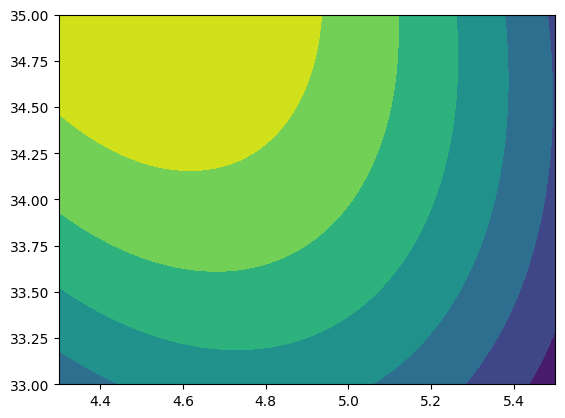

4.518181818181818
35.0


In [133]:
# TODO:
# 1. Store the predicted optimum (c_star, T_star, rate_star)
# -- you'll reuse it in Step 4.\

# 2. Run 1-2 confirmation experiments at (or near) your predicted optimum
# and compare the observed rate to the model's prediction.


plt.contourf(c_mesh, t_mesh, rate(c_mesh, t_mesh))
plt.show()

max_rate = rate(c_mesh, t_mesh).max()
max_rate_idx = np.unravel_index(np.argmax(rate(c_mesh, t_mesh), axis=None), rate(c_mesh, t_mesh).shape)
c_star = c_mesh[max_rate_idx]
T_star = t_mesh[max_rate_idx]
print(c_star)
print(T_star)

---
## Step 4 — How Sure Are You? A Confidence Interval (3:00–3:45)

- [ ] Run 8-10 replicate experiments at your predicted optimum (same T*, c*, and rpm every time).
- [ ] Compute the sample mean and standard deviation of the resulting rates
- [ ] Build a 95% confidence interval on the true mean rate there (→ **Checkpoint 4a**)
- [ ] Check whether the OVAT baseline (5.77 mol/s) and your model's predicted rate (Checkpoint 3b) fall inside or outside your CI
- [ ] Reflect on the sample-size / CI-width trade-off (→ **Checkpoint 4b**)

In [139]:
# TODO: run 8-10 replicate experiments at (c_star, T_star), same settings
# every call. log() the results.
from plant_client import run_experiment, leaderboard

result = run_experiment(T = [35], c = [4.518181818181818], rpm = [500], name='optimal8')
result
log(result)

Team 'Labgrp7': 1 experiment(s) this call, 43 total so far.


,T,c,rpm,rate
0,20.000000,1.500000,300,3.4060
1,20.000000,1.500000,700,3.3705
2,20.000000,2.500000,300,4.9949
3,20.000000,2.500000,700,4.8638
4,30.000000,1.500000,300,6.1447
5,30.000000,1.500000,700,6.0213
6,30.000000,2.500000,300,7.6661
7,30.000000,2.500000,700,7.4727
8,31.000000,3.103500,500,8.2375
9,32.000000,3.707000,500,8.4722


In [140]:
# TODO: compute mean, standard deviation (ddof=1), and a 95% confidence
# interval on the mean rate. Use scipy.stats.t.ppf(0.975, df=n-1) for the
# critical value -- same one-sample CI construction as Part III.
# Then check: does 5.77 (OVAT) fall inside your CI? Does your Step 3
# predicted rate (rate_star) fall inside your CI?

# Filter history for the optimal runs (assuming c_star, T_star, rpm_fixed are defined)
optimal_runs = history[(history['T'] == T_star) &
                       (history['c'] == c_star) &
                       (history['rpm'] == rpm_fixed)]

# Extract the rates
rates = optimal_runs['rate']

# Number of samples
n = len(rates)

# Calculate mean and standard deviation
mean_rate = rates.mean()
std_dev_rate = rates.std(ddof=1) # ddof=1 for sample standard deviation

# Calculate standard error of the mean
std_err_mean = std_dev_rate / np.sqrt(n)

# Degrees of freedom for t-distribution
df = n - 1

# Critical t-value for 95% confidence interval (two-tailed)
# alpha = 0.05, so we need ppf(0.975)
t_critical = t_dist.ppf(0.975, df=df)

# Margin of error
margin_of_error = t_critical * std_err_mean

# Confidence interval
ci_lower = mean_rate - margin_of_error
ci_upper = mean_rate + margin_of_error

print(f"Vidējais ātrums: {mean_rate:.4f}")
print(f"Standarta novirze: {std_dev_rate:.4f}")
print(f"Paraugu skaits (n): {n}")
print(f"Brīvības pakāpes (df): {df}")
print(f"Kritiskā t-vērtība: {t_critical:.4f}")
print(f"Kļūdas robeža: {margin_of_error:.4f}")
print(f"95% Ticamības intervāls: [{ci_lower:.4f}, {ci_upper:.4f}]")

# Check against OVAT baseline and predicted rate_star
ovat_baseline = 5.77
rate_star = max_rate # from previous cell output

print(f"OVAT bāzes vērtība ({ovat_baseline:.2f}) ietilpst TI: {ci_lower <= ovat_baseline <= ci_upper}")
print(f"Prognozētais rate_star ({rate_star:.4f}) ietilpst TI: {ci_lower <= rate_star <= ci_upper}")


Vidējais ātrums: 8.8743
Standarta novirze: 0.1330
Paraugu skaits (n): 6
Brīvības pakāpes (df): 5
Kritiskā t-vērtība: 2.5706
Kļūdas robeža: 0.1396
95% Ticamības intervāls: [8.7346, 9.0139]
OVAT bāzes vērtība (5.77) ietilpst TI: False
Prognozētais rate_star (8.9834) ietilpst TI: True


In [141]:
# TODO (Checkpoint 4b): using your own n and CI half-width, work out
# roughly how many replicates you'd need to halve the half-width
# (half-width shrinks with 1/sqrt(n)). Is that trade worth it given the
# contest rewards fewer experiments? Write your reasoning on the answer
# sheet, not just the number here.

# Current number of replicates (n)
current_n = n # From previous cell d1aa675c

# Current margin of error
current_margin_of_error = margin_of_error # From previous cell d1aa675c

# To halve the half-width, we need to find new_n such that new_margin_of_error = current_margin_of_error / 2.
# Since margin_of_error is proportional to 1/sqrt(n), we have:
# new_margin_of_error / current_margin_of_error = sqrt(current_n) / sqrt(new_n)
# 1/2 = sqrt(current_n) / sqrt(new_n)
# sqrt(new_n) = 2 * sqrt(current_n)
# new_n = (2 * sqrt(current_n))^2 = 4 * current_n

new_n_to_halve_half_width = 4 * current_n

print(f"Pašreizējais atkārtojumu skaits (n): {current_n}")
print(f"Pašreizējā kļūdas robeža: {current_margin_of_error:.4f}")
print(f"Aptuveni nepieciešamais atkārtojumu skaits, lai samazinātu kļūdas robežu uz pusi: {new_n_to_halve_half_width}")


Pašreizējais atkārtojumu skaits (n): 6
Pašreizējā kļūdas robeža: 0.1396
Aptuveni nepieciešamais atkārtojumu skaits, lai samazinātu kļūdas robežu uz pusi: 24


---
## Wrap-up (3:45–4:00)

- [ ] Check your final experiment count and best rate with `leaderboard()`
- [ ] Compute your % improvement over the OVAT baseline of 5.77 mol/s
- [ ] Finalise your answer sheet (Checkpoints 1a–4c)

In [42]:
# TODO: leaderboard() and a final summary print of best rate found,
# total experiments used, and % improvement over 5.77 mol/s.
# best rate - 8.975mol/s
# total experiments - 43
# improvement - 64.29 %